In [9]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib
import qRegNN_SQR as qrnn
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
from torchsummary import summary

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


In [10]:
data = np.load("SQR_models/data.npy")[:2000000]
bkg = np.load("SQR_models/bkg.npy")[:2000000]
names = list(np.load("SQR_models/names.npy"))
j1_varDict = {"pt":"jet1_pt",
              "eta":"jet1_eta",
              "phi":"jet1_phi",
              "dEta":"dEta",
              "MET":"MET",
              "m":r"$M_{j1}$",
              "tau21":r"Jet 1 $\tau_{21}$",
              "tau32":r"Jet 1 $\tau_{32}$",
              "tau43":r"Jet 1 $\tau_{43}$",
              "tauS":r"Jet 1 $\tau_s$",
              "pb":r"Jet 1 $P_b$",
              "npf":r"Jet 1 $n_{pf}$"}

d = {n:data[:,names.index(j1_varDict[n])].reshape(-1,1) for n in j1_varDict.keys()}
b = {n:bkg[:,names.index(j1_varDict[n])].reshape(-1,1) for n in j1_varDict.keys()}

trainVars = ['jet1_phi',"dEta","MET"]

# Try a NF + integration

Train bkg
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Adjusting learning rate of group 0 to 1.0000e-04.
Loss:  6.027173
Adjusting learning rate of group 0 to 9.9978e-05.
Loss:  5.839294
Adjusting learning rate of group 0 to 9.9911e-05.
Loss:  5.764292
Adjusting learning rate of group 0 to 9.9800e-05.
Loss:  5.7136536
Adjusting learning rate of group 0 to 9.9645e-05.
Loss:  5.68048
Adjusting learning rate of group 0 to 9.9446e-05.
Loss:  5.6474333
Adjusting learning rate of group 0 to 9.9203e-05.
Loss:  5.6024075
Adjusting learning rate of group 0 to 9.8916e-05.
Loss:  5.587343
Adjusting learning rate of group 0 to 9.8586e-05.
Loss:  5.588129
Adjusting learning rate of group 0 to 9.8213e-05.
Loss:  5.563952
Adjusting learning rate of group 0 to 9.7798e-05.
Loss:  5.562025
Adjusting learning rate of group 0 to 9.7340e-05.
Loss:  5.56571
Adjusting learning rate of group 0 to 9.6840e-05.
Loss:  5.552514
Adjusting learning rate of group 0 to 9.6299e-05

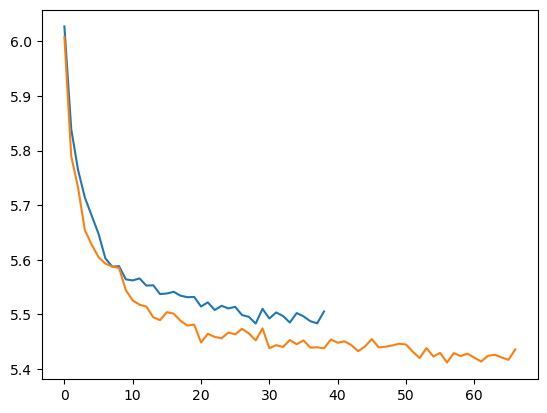

In [11]:
context_vars = ["eta","phi","npf"]
fit_vars = ["tau21"]
train_vars = context_vars+fit_vars
nTrain = 100000
bs=nTrain//10
bkg_train = np.concatenate([b[v][:nTrain] for v in train_vars],axis=1)
data_train = np.concatenate([d[v][:nTrain] for v in train_vars],axis=1)
bkg_test = np.concatenate([b[v][nTrain:nTrain+1000000] for v in train_vars],axis=1)
data_test = np.concatenate([d[v][nTrain:nTrain+1000000] for v in train_vars],axis=1)

bkg_train_iterator = utils.DataLoader(torch.tensor(bkg_train),batch_size=bs,shuffle=True,generator=torch.Generator(device='cuda'))
data_train_iterator = utils.DataLoader(torch.tensor(data_train),batch_size=bs,shuffle=True,generator=torch.Generator(device='cuda'))

print("Train bkg")
bkg_flow, min_loss, bkg_losses = hf.train_NF(bkg_train_iterator,'test',flow_type='NSQUAD',num_features=len(train_vars),
                                                  tail_bound=10,hidden_features=120,num_layers=6,
                                                  num_bins=10,num_blocks_per_layer=4,
                                                  learning_rate=1e-4,patience=10,
                                                  save_model=False,num_iter=100)
print("Train data")
data_flow, data_loss, data_losses = hf.train_NF(data_train_iterator,'test',flow_type='NSQUAD',num_features=len(train_vars),
                                                  tail_bound=10,hidden_features=120,num_layers=6,
                                                  num_bins=10,num_blocks_per_layer=4,
                                                  learning_rate=1e-4,patience=10,
                                                  save_model=False,num_iter=100)

plt.plot(np.arange(len(bkg_losses)),bkg_losses)
plt.plot(np.arange(len(data_losses)),data_losses)

In [4]:
!nvidia-smi

Thu Jan 12 11:40:59 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.73.01    Driver Version: 460.73.01    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  On   | 00000004:04:00.0 Off |                    0 |
| N/A   46C    P0    57W / 300W |   1383MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

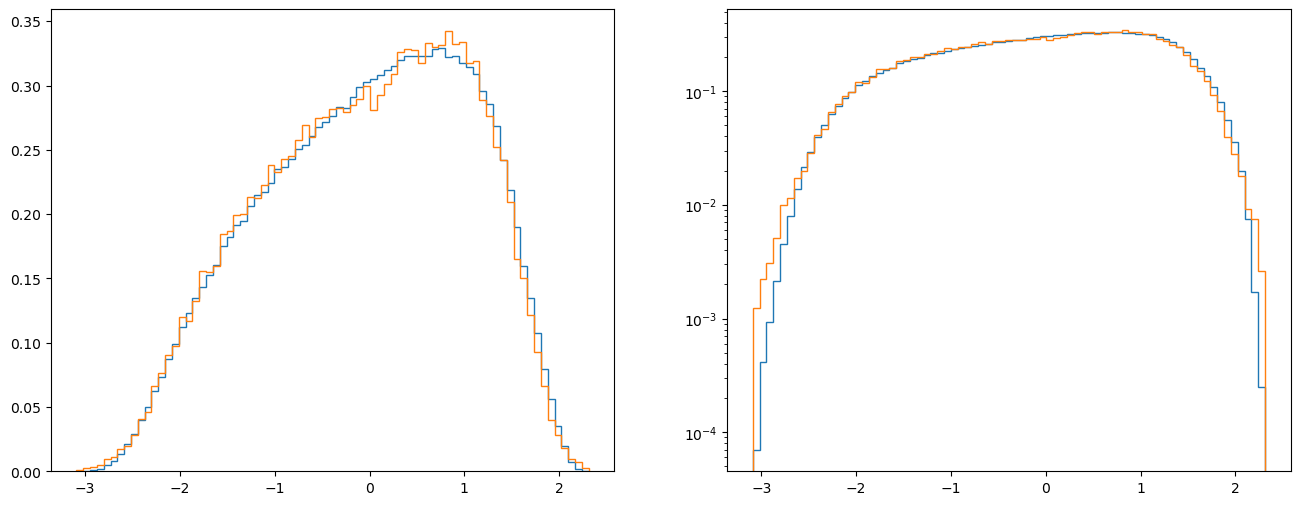

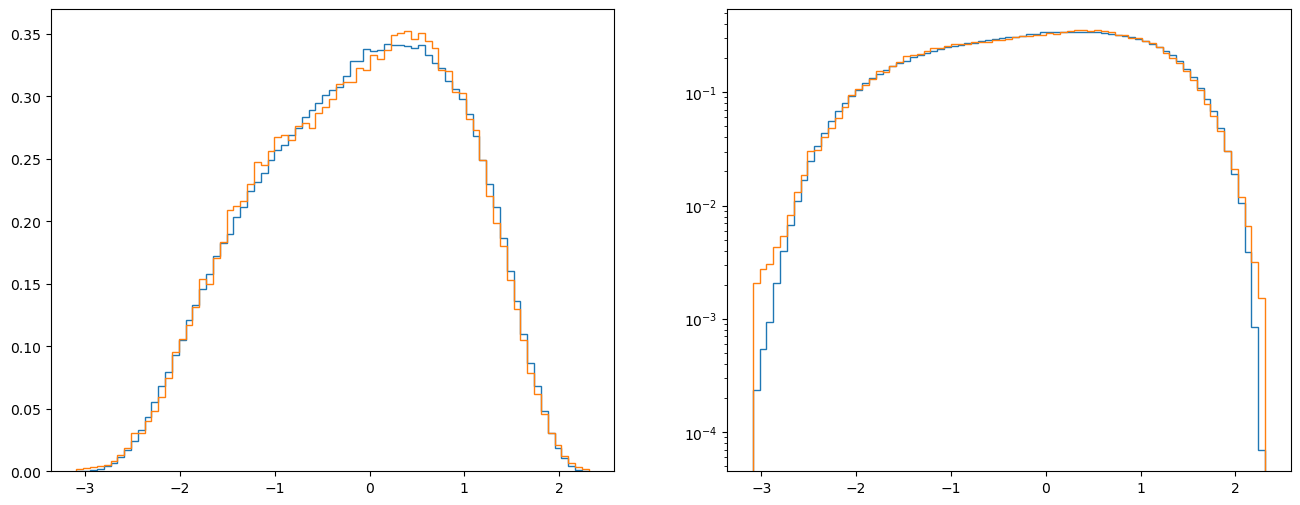

In [12]:
sampList = []
for i in range(100):
    lo = 1000*i
    with torch.no_grad():
        sampList.append(bkg_flow.sample(1000).detach().cpu().numpy())
samples=np.concatenate(sampList,axis=0)
plt.figure(figsize=(16,6))
plt.subplot(121)
c1,b1,p1 = plt.hist(bkg_test[:,-1],bins=75,histtype='step',density=True)
h2 = plt.hist(samples[:,-1],bins=b1,histtype='step',density=True)
plt.subplot(122)
c1,b1,p1 = plt.hist(bkg_test[:,-1],bins=b1,histtype='step',density=True)
h2 = plt.hist(samples[:,-1],bins=b1,histtype='step',density=True)
plt.yscale('log')

sampList = []
for i in range(100):
    lo = 1000*i
    with torch.no_grad():
        sampList.append(data_flow.sample(1000).detach().cpu().numpy())
samples=np.concatenate(sampList,axis=0)
plt.figure(figsize=(16,6))
plt.subplot(121)
c1,b1,p1 = plt.hist(data_test[:,-1],bins=b1,histtype='step',density=True)
h2 = plt.hist(samples[:,-1],bins=b1,histtype='step',density=True)
plt.subplot(122)
c1,b1,p1 = plt.hist(data_test[:,-1],bins=b1,histtype='step',density=True)
h2 = plt.hist(samples[:,-1],bins=b1,histtype='step',density=True)
plt.yscale('log')

In [6]:
!nvidia-smi

Thu Jan 12 11:41:16 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.73.01    Driver Version: 460.73.01    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  On   | 00000004:04:00.0 Off |                    0 |
| N/A   45C    P0    57W / 300W |   1383MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

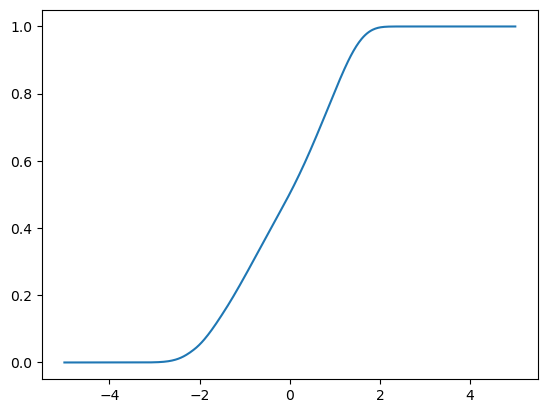

In [13]:
x = np.linspace(-5,5,num=500)
bs = x[1]-x[0]
fixed = torch.tensor(bkg_test[983]).view(1,-1)
fixed = fixed.repeat((len(x),1))
fixed[:,-1] = torch.tensor(x)
probs = np.exp(bkg_flow.eval_log_prob(fixed)[0])
del fixed
torch.cuda.empty_cache()
plt.plot(x,np.cumsum(bs*probs)/np.sum(bs*probs))

In [8]:
!nvidia-smi

Thu Jan 12 11:41:16 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.73.01    Driver Version: 460.73.01    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  On   | 00000004:04:00.0 Off |                    0 |
| N/A   45C    P0    57W / 300W |    989MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [14]:
ntest = 1000
npt = 100
n_it = 100
x = np.linspace(-4,4,num=npt)
bs = x[1]-x[0]
xi = np.tile(x,ntest)
pbs = []
pds = []
for i in range(n_it):
    bc = bkg_test[i*ntest:(i+1)*ntest].repeat(npt,axis=0)
    bc[:,-1] = xi
    
    bc = torch.tensor(bc,dtype=torch.float32)
    pbs.append(np.exp(bkg_flow.eval_log_prob(bc)[0]).reshape(ntest,npt))    
    pds.append(np.exp(data_flow.eval_log_prob(bc)[0]).reshape(ntest,npt))
    del bc
    torch.cuda.empty_cache()
    
pb = np.concatenate(pbs,axis=0)
pd = np.concatenate(pds,axis=0)

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/ipykernel_launcher.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  from ipykernel import kernelapp as app


In [15]:
qb = bs*np.cumsum(pb,axis=1)/np.tile(np.sum(pb,axis=1).reshape(-1,1),(1,pb.shape[1]))
qd = bs*np.cumsum(pd,axis=1)/np.tile(np.sum(pd,axis=1).reshape(-1,1),(1,pd.shape[1]))
Y = bkg_test[:ntest*n_it,-1]
Yd = data_test[:ntest*n_it,-1]
Ycorr = -999*np.ones_like(Y)
qrnn.correctAll_v2(Y,x.astype('float32'),qb,qd,Ycorr)

array([ 1.469027 , -1.2098421,  0.4886769, ..., -1.0180469, -1.9448684,
        0.5750434], dtype=float32)

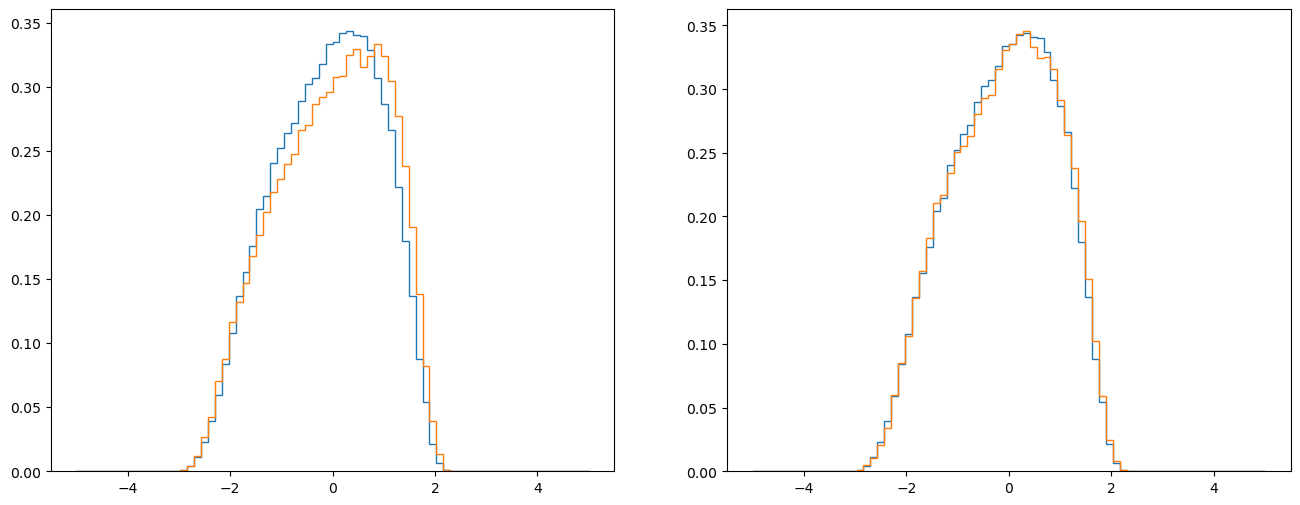

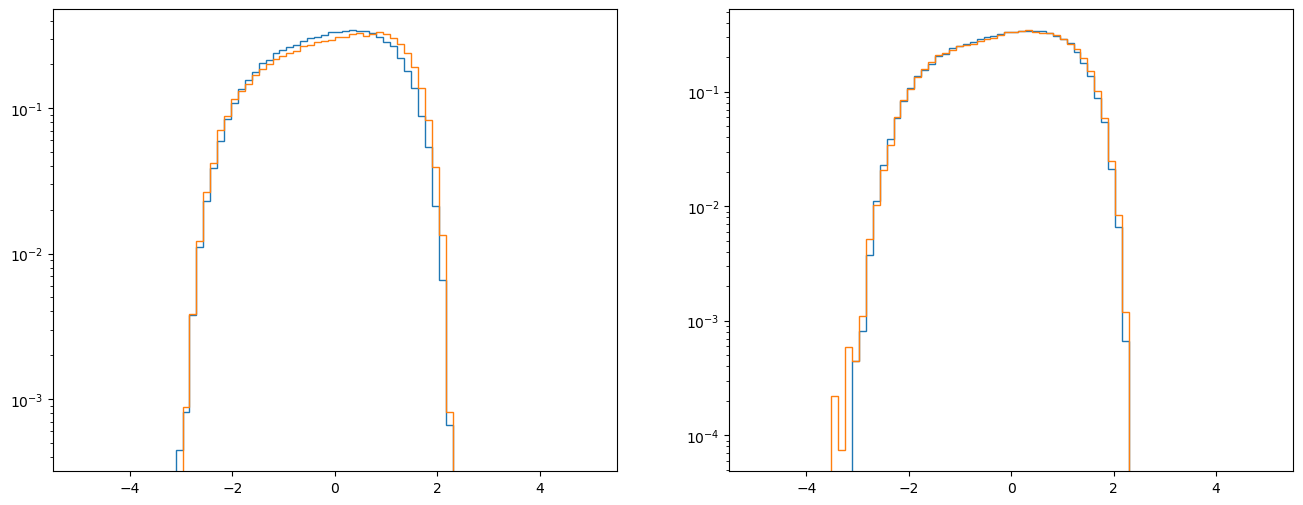

In [16]:
bins = np.linspace(-5,5,75)
plt.figure(figsize=(16,6))
plt.subplot(121)
h1 = plt.hist(Yd,bins=bins,density=True,histtype='step')
h1 = plt.hist(Y,bins=bins,density=True,histtype='step')
plt.subplot(122)
h1 = plt.hist(Yd,bins=bins,density=True,histtype='step')
h1 = plt.hist(Ycorr,bins=bins,density=True,histtype='step')

plt.figure(figsize=(16,6))
plt.subplot(121)
h1 = plt.hist(Yd,bins=bins,density=True,histtype='step')
h1 = plt.hist(Y,bins=bins,density=True,histtype='step')
plt.yscale('log')
plt.subplot(122)
h1 = plt.hist(Yd,bins=bins,density=True,histtype='step')
h1 = plt.hist(Ycorr,bins=bins,density=True,histtype='step')
plt.yscale('log')